# Cell Imports

In [1]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Optional display settings for easier notebook viewing
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

#Load Dataset

In [2]:
!rm -rf myscrapers-jsb21017
!git clone https://github.com/OPIM5512-JSB21017/myscrapers-jsb21017.git
%cd myscrapers-jsb21017

Cloning into 'myscrapers-jsb21017'...


remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (57/57), done.


remote: Compressing objects: 100% (53/53), done.


remote: Total 621 (delta 19), reused 8 (delta 2), pack-reused 564 (from 3)
Receiving objects: 100% (621/621), 1.56 MiB | 3.92 MiB/s, done.
Resolving deltas: 100% (205/205), done.


/home/runner/work/myscrapers-jsb21017/myscrapers-jsb21017/notebooks/myscrapers-jsb21017


In [3]:
#Live dataset from GCP
gcp_url = "https://storage.googleapis.com/myscrapers-jsb21017/structured/datasets/listings_master_llm.csv"

df = pd.read_csv(gcp_url)

print("Loaded dataset from GCP")
print("Shape:", df.shape)
df.head()

Loaded dataset from GCP
Shape: (504, 20)


,post_id,run_id,scraped_at,price,year,make,model,mileage,body_type,color,condition,title_status,city,state,number_of_owners,seller_type,llm_provider,llm_model,llm_ts,source_txt
0,7919994197,20260326140018,2026-03-26T14:00:18Z,25000.0,2001,Ford,Mustang GT,6793.0,coupe,yellow,like new,clean,NaN,NaN,NaN,NaN,vertex,gemini-2.5-flash,2026-03-26T14:58:15.629012Z,scrapes/20260326140018/7919994197.txt
1,7920019541,20260326150006,2026-03-26T15:00:06Z,1950.0,2012,Chrysler,town & country,165000.0,minivan,NaN,good,clean,NaN,NaN,NaN,NaN,vertex,gemini-2.5-flash,2026-03-26T15:12:04.230650Z,scrapes/20260326150006/7920019541.txt
2,7920234052,20260326220006,2026-03-26T22:00:06Z,3400.0,2011,Honda,Civic,56000.0,sedan,white,excellent,clean,NaN,NaN,NaN,NaN,vertex,gemini-2.5-flash,2026-03-26T22:12:17.734448Z,scrapes/20260326220006/7920234052.txt
3,7920279528,20260326220006,2026-03-26T22:00:06Z,9998.0,2016,Subaru,Crosstrek,147973.0,Wagon,White,NaN,clean,NaN,NaN,NaN,NaN,vertex,gemini-2.5-flash,2026-03-26T22:12:21.584331Z,scrapes/20260326220006/7920279528.txt
4,7920404383,20260326180046,2026-03-26T18:00:46Z,5500.0,1995,chevrolet,camaro,188000.0,hatchback,Plum purple,excellent,missing,NaN,NaN,NaN,NaN,vertex,gemini-2.5-flash,2026-03-26T18:12:21.118381Z,scrapes/20260326180046/7920404383.txt


#Inspect Columns

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Columns:
['post_id', 'run_id', 'scraped_at', 'price', 'year', 'make', 'model', 'mileage', 'body_type', 'color', 'condition', 'title_status', 'city', 'state', 'number_of_owners', 'seller_type', 'llm_provider', 'llm_model', 'llm_ts', 'source_txt']

Data types:
post_id               int64
run_id                int64
scraped_at              str
price               float64
year                  int64
make                    str
model                   str
mileage             float64
body_type               str
color                   str
condition               str
title_status            str
city                    str
state                   str
number_of_owners    float64
seller_type             str
llm_provider            str
llm_model               str
llm_ts                  str
source_txt              str
dtype: object

Missing values:
post_id               0
run_id                0
scraped_at            0
price                 9
year                  0
make                  0
model 

#Basic Cleaning

In [5]:
# Drop rows where target is missing
df = df.dropna(subset=["price"]).copy()

# Drop the rows missing mileage
df = df.dropna(subset=["mileage"]).copy()

# Remove outliers
df = df[(df["price"] > 500) & (df["price"] < 150000)].copy()

# Number_of_owners is mostly missing so we fill with 1 which is the reasonable default option (if it was different, it would most likely be specified)
df["number_of_owners"] = df["number_of_owners"].fillna(1)

# Fill categorical values
categorical_cols = [
    "body_type",
    "color",
    "condition",
    "title_status",
    "city",
    "state",
    "seller_type"
]

for col in categorical_cols:
    df[col] = df[col].fillna("unknown")

# Simplify condition (too inconsistent if I don't)
def simplify_condition(x):
    if pd.isna(x):
        return "unknown"
    x = str(x).lower()
    if "new" in x:
        return "like_new"
    if "excellent" in x:
        return "excellent"
    if "good" in x:
        return "good"
    if "fair" in x:
        return "fair"
    return "other"

df["condition"] = df["condition"].apply(simplify_condition)

# Simplify seller type (too inconsistent if I don't)
def simplify_seller(x):
    if pd.isna(x):
        return "unknown"
    x = str(x).lower()
    if "dealer" in x:
        return "dealer"
    if "private" in x:
        return "private"
    return "unknown"

df["seller_type"] = df["seller_type"].apply(simplify_seller)

# Print a final check
print("Final shape:", df.shape)
print("\nRemaining missing values:")
print(df.isna().sum())

df.head()

Final shape: (492, 20)

Remaining missing values:
post_id             0
run_id              0
scraped_at          0
price               0
year                0
make                0
model               0
mileage             0
body_type           0
color               0
condition           0
title_status        0
city                0
state               0
number_of_owners    0
seller_type         0
llm_provider        0
llm_model           0
llm_ts              0
source_txt          0
dtype: int64


,post_id,run_id,scraped_at,price,year,make,model,mileage,body_type,color,condition,title_status,city,state,number_of_owners,seller_type,llm_provider,llm_model,llm_ts,source_txt
0,7919994197,20260326140018,2026-03-26T14:00:18Z,25000.0,2001,Ford,Mustang GT,6793.0,coupe,yellow,like_new,clean,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T14:58:15.629012Z,scrapes/20260326140018/7919994197.txt
1,7920019541,20260326150006,2026-03-26T15:00:06Z,1950.0,2012,Chrysler,town & country,165000.0,minivan,unknown,good,clean,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T15:12:04.230650Z,scrapes/20260326150006/7920019541.txt
2,7920234052,20260326220006,2026-03-26T22:00:06Z,3400.0,2011,Honda,Civic,56000.0,sedan,white,excellent,clean,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T22:12:17.734448Z,scrapes/20260326220006/7920234052.txt
3,7920279528,20260326220006,2026-03-26T22:00:06Z,9998.0,2016,Subaru,Crosstrek,147973.0,Wagon,White,other,clean,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T22:12:21.584331Z,scrapes/20260326220006/7920279528.txt
4,7920404383,20260326180046,2026-03-26T18:00:46Z,5500.0,1995,chevrolet,camaro,188000.0,hatchback,Plum purple,excellent,missing,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T18:12:21.118381Z,scrapes/20260326180046/7920404383.txt


#Derived Features

In [6]:
# vehicle_age and mileage_per_year are helpful modeling features.
# They often give the model more useful signal than raw year alone.
# Also added "is high mileage" and "is newer car" to help the model

current_year = datetime.now().year

# Vehicle age
df["vehicle_age"] = current_year - df["year"]

# If age is 0 or negative, make it missing
df.loc[df["vehicle_age"] <= 0, "vehicle_age"] = np.nan

# Mileage per year
df["mileage_per_year"] = df["mileage"] / df["vehicle_age"]

# Replace inf with NaN just in case
df["mileage_per_year"] = df["mileage_per_year"].replace([np.inf, -np.inf], np.nan)

#Is High Milage
df["is_high_mileage"] = (df["mileage"] > 100000).astype(int)

#Is Newer Car
df["is_newer_car"] = (df["vehicle_age"] < 5).astype(int)

df[["year", "mileage", "vehicle_age", "mileage_per_year", "is_newer_car", "is_high_mileage"]].head()

,year,mileage,vehicle_age,mileage_per_year,is_newer_car,is_high_mileage
0,2001,6793.0,25.0,271.720000,0,0
1,2012,165000.0,14.0,11785.714286,0,1
2,2011,56000.0,15.0,3733.333333,0,0
3,2016,147973.0,10.0,14797.300000,0,1
4,1995,188000.0,31.0,6064.516129,0,1


#Time-Based Split

In [7]:
input_path = "artifacts/input/listings_master_llm.csv"

# The df variable was already loaded and cleaned in previous cells.
# We do not need to reload it here, as it would overwrite the cleaned state.

print("Using input file for time-based split:", input_path)
print("Shape of cleaned df before split:", df.shape)
print("Head of cleaned df before split:")
display(df.head())

Using input file for time-based split: artifacts/input/listings_master_llm.csv
Shape of cleaned df before split: (492, 24)
Head of cleaned df before split:


,post_id,run_id,scraped_at,price,year,make,model,mileage,body_type,color,condition,title_status,city,state,number_of_owners,seller_type,llm_provider,llm_model,llm_ts,source_txt,vehicle_age,mileage_per_year,is_high_mileage,is_newer_car
0,7919994197,20260326140018,2026-03-26T14:00:18Z,25000.0,2001,Ford,Mustang GT,6793.0,coupe,yellow,like_new,clean,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T14:58:15.629012Z,scrapes/20260326140018/7919994197.txt,25.0,271.720000,0,0
1,7920019541,20260326150006,2026-03-26T15:00:06Z,1950.0,2012,Chrysler,town & country,165000.0,minivan,unknown,good,clean,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T15:12:04.230650Z,scrapes/20260326150006/7920019541.txt,14.0,11785.714286,1,0
2,7920234052,20260326220006,2026-03-26T22:00:06Z,3400.0,2011,Honda,Civic,56000.0,sedan,white,excellent,clean,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T22:12:17.734448Z,scrapes/20260326220006/7920234052.txt,15.0,3733.333333,0,0
3,7920279528,20260326220006,2026-03-26T22:00:06Z,9998.0,2016,Subaru,Crosstrek,147973.0,Wagon,White,other,clean,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T22:12:21.584331Z,scrapes/20260326220006/7920279528.txt,10.0,14797.300000,1,0
4,7920404383,20260326180046,2026-03-26T18:00:46Z,5500.0,1995,chevrolet,camaro,188000.0,hatchback,Plum purple,excellent,missing,unknown,unknown,1.0,unknown,vertex,gemini-2.5-flash,2026-03-26T18:12:21.118381Z,scrapes/20260326180046/7920404383.txt,31.0,6064.516129,1,0


In [8]:
# The assignment says to use past data to predict today's listings.
# So I should NOT use a random split.
# I sort by scraped_at and split chronologically.

df = df.sort_values("scraped_at").reset_index(drop=True)

n = len(df)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

# For GridSearchCV, we combine train + validation and keep test untouched
train_valid_df = df.iloc[:valid_end].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

print("\nDate ranges:")
print("Train:", train_df["scraped_at"].min(), "to", train_df["scraped_at"].max())
print("Valid:", valid_df["scraped_at"].min(), "to", valid_df["scraped_at"].max())
print("Test :", test_df["scraped_at"].min(), "to", test_df["scraped_at"].max())

Train shape: (344, 24)
Validation shape: (74, 24)
Test shape: (74, 24)

Date ranges:
Train: 2026-03-26T14:00:18Z to 2026-04-04T16:00:43Z
Valid: 2026-04-04T16:00:43Z to 2026-04-04T18:00:13Z
Test : 2026-04-04T18:00:13Z to 2026-04-04T19:00:06Z


#Define target and features

In [9]:
# These features come from my LLM ETL plus derived variables.

target = "price"

features = [
    "year",
    "mileage",
    "body_type",
    "color",
    "condition",
    "title_status",
    #"city", (too much noise)
    "state",
    "number_of_owners",
    "seller_type",
    "vehicle_age",
    "mileage_per_year",
    "is_high_mileage",
    "is_newer_car",
]

#few expensive cars, so I log the target
y_train_valid = np.log1p(train_valid_df[target])

X_train_valid = train_valid_df[features].copy()
X_test = test_df[features].copy()

y_test = np.log1p(test_df[target])

print("Training features shape:", X_train_valid.shape)
print("Test features shape:", X_test.shape)


Training features shape: (418, 13)
Test features shape: (74, 13)


#Preprocessing pipeline

In [10]:
# Numeric columns get median imputation.
# Categorical columns get mode imputation + one hot encoding.

numeric_features = [
    "year",
    "mileage",
    "number_of_owners",
    "vehicle_age",
    "mileage_per_year",
    "is_high_mileage",
    "is_newer_car",
]

categorical_features = [
    "body_type",
    "color",
    "condition",
    "title_status",
    #"city",
    "state",
    "seller_type",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

#Build and tune model

In [11]:
# I use GridSearchCV for hyperparameter tuning.

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 18],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_valid, y_train_valid)

best_model = grid.best_estimator_

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV score (negative MAE):")
print(grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


Best parameters:
{'model__max_depth': 18, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV score (negative MAE):
-0.3896524039461358


#Evaluate the model

In [12]:
# Required metrics:
# MAE, MAPE, RMSE, Bias

y_pred_log = best_model.predict(X_test)

# Convert back to price scale
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)

# manual square root
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

mape = mean_absolute_percentage_error(y_test_actual, y_pred)
bias = np.mean(y_pred - y_test_actual)

metrics_df = pd.DataFrame([
    {
        "run_ts": datetime.now().isoformat(),
        "n_rows": len(df),
        "train_valid_rows": len(train_valid_df),
        "test_rows": len(test_df),
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "bias": bias,
        "best_params": str(grid.best_params_),
    }
])

print("Model metrics:")
display(metrics_df)

Model metrics:


,run_ts,n_rows,train_valid_rows,test_rows,mae,rmse,mape,bias,best_params
0,2026-04-04T19:41:06.753366,492,418,74,4150.911545,11106.314097,0.300614,-2764.026135,"{'model__max_depth': 18, 'model__min_samples_l..."


#Save Predictions

In [13]:
# This creates the predictions artifact.

os.makedirs("artifacts/predictions", exist_ok=True)

preds_df = test_df[["post_id", "scraped_at"]].copy()

# Use the CORRECT scale
preds_df["actual_price"] = y_test_actual
preds_df["predicted_price"] = y_pred

preds_df["error"] = preds_df["predicted_price"] - preds_df["actual_price"]

predictions_path = "artifacts/predictions/latest_predictions.csv"
preds_df.to_csv(predictions_path, index=False)

print("Saved predictions to:", predictions_path)
preds_df.head()

Saved predictions to: artifacts/predictions/latest_predictions.csv


,post_id,scraped_at,actual_price,predicted_price,error
418,7922813137,2026-04-04T18:00:13Z,5999.0,5373.521351,-625.478649
419,7922411334,2026-04-04T18:00:13Z,8999.0,9002.614266,3.614266
420,7922176112,2026-04-04T18:00:13Z,9885.0,8778.535443,-1106.464557
421,7925306856,2026-04-04T18:00:13Z,8800.0,10065.411138,1265.411138
422,7922955918,2026-04-04T18:00:13Z,3900.0,2962.821657,-937.178343


#Permutation Importance

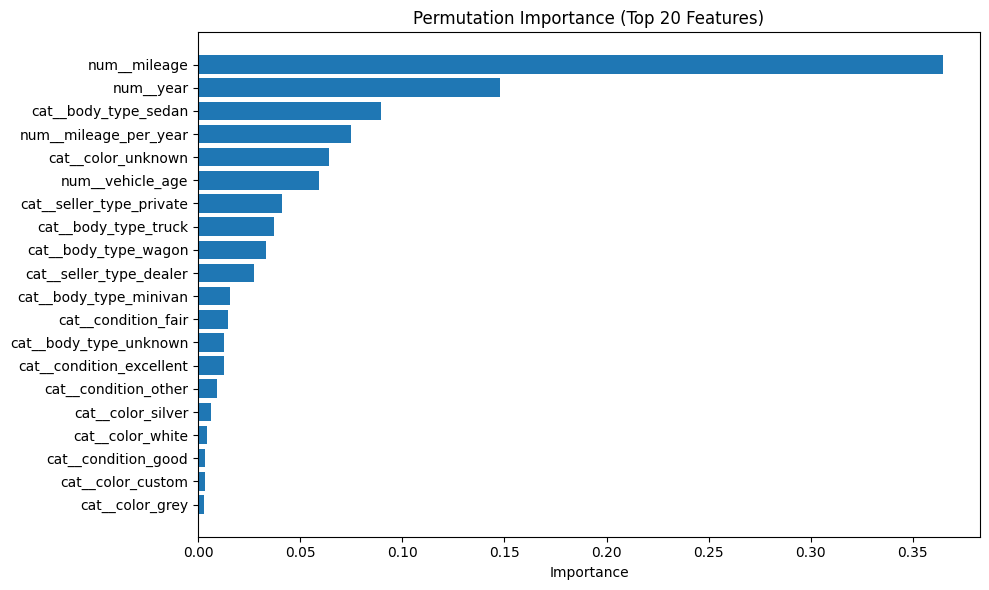

Saved importance CSV to: artifacts/importance/permutation_importance.csv
Saved importance plot to: artifacts/importance/permutation_importance.png


,feature,importance_mean,importance_std
1,num__mileage,0.364621,0.072501
0,num__year,0.147845,0.054351
20,cat__body_type_sedan,0.089418,0.019817
4,num__mileage_per_year,0.075061,0.012117
56,cat__color_unknown,0.064256,0.026230
3,num__vehicle_age,0.059407,0.031783
75,cat__seller_type_private,0.041095,0.012110
21,cat__body_type_truck,0.037325,0.009792
24,cat__body_type_wagon,0.033349,0.008097
74,cat__seller_type_dealer,0.027186,0.010326


In [14]:
# This creates the feature importance artifact
os.makedirs("artifacts/importance", exist_ok=True)

# Get the preprocessor from the best_model pipeline
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Transform X_test to get the processed features
X_test_processed = preprocessor_fitted.transform(X_test)

# Get the names of the processed features
feature_names = preprocessor_fitted.get_feature_names_out()

# Get the final model (RandomForestRegressor) from the best_model pipeline
final_model = best_model.named_steps["model"]

perm = permutation_importance(
    estimator=final_model, # Use the final model directly
    X=X_test_processed.toarray(),    # Convert sparse matrix to dense array
    y=y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_csv_path = "artifacts/importance/permutation_importance.csv"
importance_png_path = "artifacts/importance/permutation_importance.png"

importance_df.to_csv(importance_csv_path, index=False)

# Plot top 20 features
plt.figure(figsize=(10, 6))
top20 = importance_df.head(20).sort_values("importance_mean")
plt.barh(top20["feature"], top20["importance_mean"])
plt.title("Permutation Importance (Top 20 Features)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(importance_png_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved importance CSV to:", importance_csv_path)
print("Saved importance plot to:", importance_png_path)
importance_df.head(10)

#PDPs for top 3 features

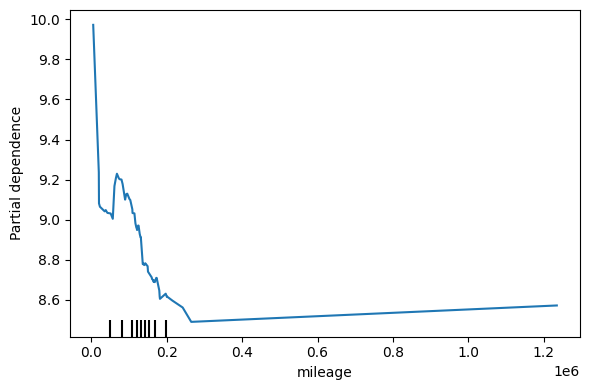

Saved PDP to: artifacts/pdp/pdp_mileage.png


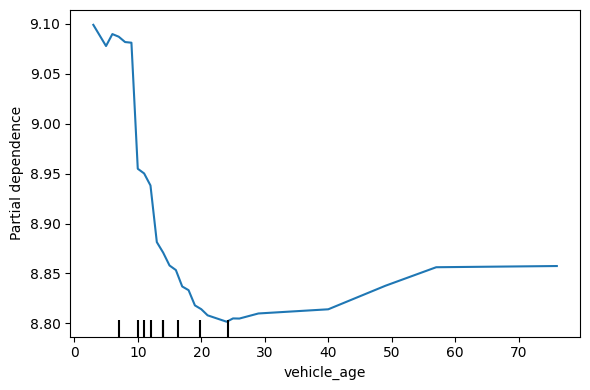

Saved PDP to: artifacts/pdp/pdp_vehicle_age.png


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


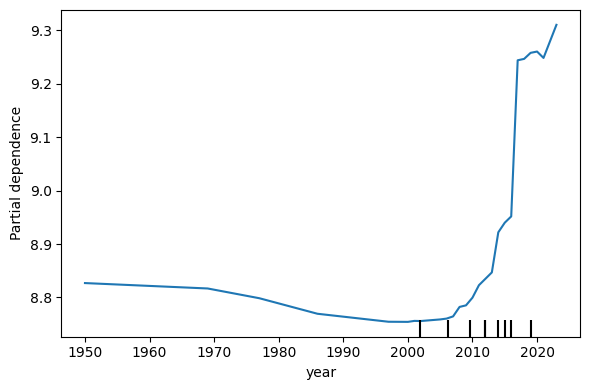

Saved PDP to: artifacts/pdp/pdp_year.png


In [15]:
# For simplicity, I use base numeric features that are easy to interpret.
# This avoids issues with one-hot encoded transformed feature names.

os.makedirs("artifacts/pdp", exist_ok=True)

pdp_features = ["mileage", "vehicle_age", "year"]

for feat in pdp_features:
    fig, ax = plt.subplots(figsize=(6, 4))

    PartialDependenceDisplay.from_estimator(
        estimator=best_model,
        X=X_test,
        features=[feat],
        ax=ax
    )

    plt.tight_layout()
    output_path = f"artifacts/pdp/pdp_{feat}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved PDP to:", output_path)

#Save Model History

In [16]:
input_path = "artifacts/input/listings_master_llm.csv"
df = pd.read_csv(input_path)

print("Using input file:", input_path)
print("Shape:", df.shape)
print(df.head())

Using input file: artifacts/input/listings_master_llm.csv
Shape: (493, 20)
      post_id          run_id            scraped_at    price  year       make           model   mileage  body_type        color  condition title_status city state  number_of_owners seller_type  \
0  7919994197  20260326140018  2026-03-26T14:00:18Z  25000.0  2001       Ford      Mustang GT    6793.0      coupe       yellow   like new        clean  NaN   NaN               NaN         NaN   
1  7920019541  20260326150006  2026-03-26T15:00:06Z   1950.0  2012   Chrysler  town & country  165000.0    minivan          NaN       good        clean  NaN   NaN               NaN         NaN   
2  7920234052  20260326220006  2026-03-26T22:00:06Z   3400.0  2011      Honda           Civic   56000.0      sedan        white  excellent        clean  NaN   NaN               NaN         NaN   
3  7920279528  20260326220006  2026-03-26T22:00:06Z   9998.0  2016     Subaru       Crosstrek  147973.0      Wagon        White        NaN   

In [17]:
# This file is what the trending notebook will use later.

import os
import pandas as pd

os.makedirs("artifacts/history", exist_ok=True)

history_path = "artifacts/history/model_metrics_history.csv"

# If the file exists, load it and append the new run
if os.path.exists(history_path):
    old_history = pd.read_csv(history_path)
    new_history = pd.concat([old_history, metrics_df], ignore_index=True)
else:
    new_history = metrics_df.copy()

# Only remove exact duplicates by run timestamp
new_history = new_history.drop_duplicates(subset=["run_ts"], keep="last")

# Save back to disk
new_history.to_csv(history_path, index=False)

print("Saved metrics history to:", history_path)
print("Rows in saved history:", len(new_history))
new_history.tail()

Saved metrics history to: artifacts/history/model_metrics_history.csv
Rows in saved history: 4


,run_ts,n_rows,train_valid_rows,test_rows,mae,rmse,mape,bias,best_params
0,2026-04-04T14:43:34.959503,464,394,70,5613.042967,14678.357950,0.452199,-3624.109393,"{'model__max_depth': None, 'model__min_samples..."
1,2026-04-04T17:41:05.174781,481,408,73,4363.087866,8569.449521,0.724027,-1335.177808,"{'model__max_depth': 18, 'model__min_samples_l..."
2,2026-04-04T19:02:58.290170,486,413,73,3352.644165,9396.927712,0.304545,-1852.224773,"{'model__max_depth': 18, 'model__min_samples_l..."
3,2026-04-04T19:41:06.753366,492,418,74,4150.911545,11106.314097,0.300614,-2764.026135,"{'model__max_depth': 18, 'model__min_samples_l..."


#Final check of saved artifacts

In [18]:
required_files = [
    "artifacts/predictions/latest_predictions.csv",
    "artifacts/importance/permutation_importance.csv",
    "artifacts/importance/permutation_importance.png",
    "artifacts/pdp/pdp_mileage.png",
    "artifacts/pdp/pdp_vehicle_age.png",
    "artifacts/pdp/pdp_year.png",
    "artifacts/history/model_metrics_history.csv",
]

for path in required_files:
    print(path, "->", os.path.exists(path))

artifacts/predictions/latest_predictions.csv -> True
artifacts/importance/permutation_importance.csv -> True
artifacts/importance/permutation_importance.png -> True
artifacts/pdp/pdp_mileage.png -> True
artifacts/pdp/pdp_vehicle_age.png -> True
artifacts/pdp/pdp_year.png -> True
artifacts/history/model_metrics_history.csv -> True
